## Automação de Tarefas: Acessando e enviando email automaticamente utilizando a biblioteca Pyautogui.
(Script criado no jupyter notebook: só funciona executando pelo jupyter)

### Problema a ser resolvido
- Buscar, de forma automática, informações de ações da bolsa de valores.
- Criar as análises solicitadas pelo Gestor.
- Enviar, automaticamente, um email com os resultados das análises.

### Bibliotecas utilizadas:
- yfinance.
- pyautogui.
- pyperclip.
- time.
- matplotlib.

In [1]:
# !pip install pyautogui

  Using cached pyautogui-0.9.54-py3-none-any.whl
  Using cached pymsgbox-2.0.1-py3-none-any.whl.metadata (4.4 kB)
  Using cached pytweening-1.2.0-py3-none-any.whl
  Using cached pyscreeze-1.0.1-py3-none-any.whl
  Using cached PyGetWindow-0.0.9-py3-none-any.whl
  Using cached MouseInfo-0.1.3-py3-none-any.whl
  Using cached PyRect-0.2.0.tar.gz (17 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached pyperclip-1.11.0-py3-none-any.whl.metadata (2.4 kB)
Using cached pymsgbox-2.0.1-py3-none-any.whl (10.0 kB)
Using cached pyperclip-1.11.0-py3-none-any.whl (11 kB)
  Created wheel for pyrect: filename=PyRect-0.2.0-py2.py3-none-any.whl size=11207 sha256=9268fe59c11cdbb73b9c6aeb6b47d34e18e96db085669503e2bdabd463116301
  Stored in directory: c:\users\tayta\appdata\local\pip\cache\wheels\1e\84\e3\83782b4a92f3d4d5b7fff5c36bf8c31922719e0695ee854cf0
Successfully built pyrect

   ------------------------- -------------- 5/8 [pygetwindo

  DEPRECATION: Building 'pyrect' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pyrect'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [1]:
import yfinance
import pyautogui
import pyperclip
import matplotlib as plt
import time

### Gerar as análise solicitadas:
- Dos últimos 6 meses.
- Cotações: máxima, mínima e atual.

Digite o código da ação: VALE3.SA


Cota máxima: 90.09
Cota mínima: 71.93
Cota máxima: 76.09


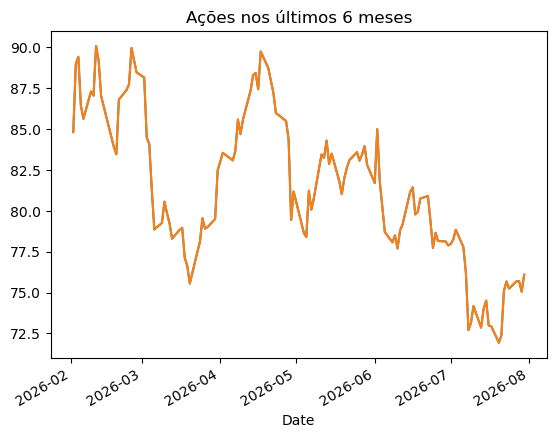

In [2]:
# Buscando informações das ações:
acao = input("Digite o código da ação:")
dados_acao = yfinance.Ticker(acao).history("6mo")
dados_close = dados_acao.Close
dados_close.plot(title="Ações nos últimos 6 meses");
dados_grafico = dados_close.plot(title="Ações nos últimos 6 meses")

cot_maxima = round(dados_close.max(),2)
cot_minima = round(dados_close.min(),2)

# última linha é sempre a atual
cot_atual = round(dados_close.iloc[-1],2)

print(f"Cota máxima: {cot_maxima}")
print(f"Cota mínima: {cot_minima}")
print(f"Cota máxima: {cot_atual}")

### Enviar email automaticamente:
- Abrir uma nova aba no navegador (CTRL + T).
- Digitar o site do email (www.gmail.com).
- Acessar o email.
- Clicar no botão escrever.
- Preecher o destinatário.
- TAB: Preencher o assunto.
- TAB: Preencher o corpo do email.
- Clicar em enviar.

In [22]:
# Configurando para dar uma pausa de 3 segundos entreos passos
pyautogui.PAUSE = 3

# Abrir uma nova aba no navegador
pyautogui.hotkey("ctrl","t")

# Acessando o Gmail
pyperclip.copy("www.gmail.com")
pyautogui.hotkey("ctrl","v")
pyautogui.hotkey("Enter")

# Clicando em escrever (cursor já fica piscando no destinatário)
pyautogui.click(x=78, y=265)

# Preencher destinatário (clicar tab)
pyperclip.copy("taytaramos@gmail.com")
pyautogui.hotkey("ctrl","v")
pyautogui.hotkey("tab")

# Preencher assunto (clicar tab)
pyperclip.copy("Análises Diárias - Ações")
pyautogui.hotkey("ctrl","v")
pyautogui.hotkey("tab")

# Escrever a mensagem do email
mensagem = f'''
Prezado Gestor,

Seguem as análises diárias da ação {acao} referentes aos últimos 6 meses:

Cota máxima: R$ {cot_maxima}
Cota mínima: R$ {cot_minima}
Cota máxima: R$ {cot_atual}

Qualquer dúvida, estou à disposição!
'''

pyperclip.copy(mensagem)
pyautogui.hotkey("ctrl","v")
pyautogui.hotkey("tab")

# Enviando email
pyautogui.click(x=1235, y=974)
pyautogui.hotkey("Enter")

# Fechando a página
pyautogui.click(x=1420, y=25)

In [21]:
# Descobrir a coordenada de onde está o botão Escrever no gmail
time.sleep(10)
pyautogui.position()

Point(x=1420, y=25)